# <font color=#0099CC>**DERIVADOS: ESTRATEGIAS CON OPCIONES**</font>

### **Fecha: 14/01/2026 | Autor: Javier Fernández Guerra**

## <font color=#0099CC>**0. INTRODUCCIÓN, ENFOQUE Y OBJETIVOS**</font>

### <font color=#336699>**0.1. INTRODUCCIÓN Y OBJETIVOS**</font>
Este Jupiter Notebook contesta al enunciado planteado en clase sobre estrategias con opciones. Se va ha:

1. Construir una estrategia concreta con opciones: **long straddle periódico sobre SPY**.
2. Modificarla para obtener una versión **delta-hedged** (calculando y usando griegas propias) con el subyacente.
3. Analizar el **P&L histórico** de ambas versiones.
4. Simular envío de órdenes: como **combo** (straddle como una sola orden), y como **patas sueltas** (call y put por separado) analizando el riesgo de legging.
5. Ver cómo se puede **neutralizar Delta con otra opción** y qué implica para Gamma, Vega y Theta.
6. Reflexión: ¿qué habría cambiado usando **SPX** en lugar de **SPY**?


### <font color=#336699>**0.2. JUSTIFICACIÓN DEL ENFOQUE UTILIZADO**</font>

Para realizar este trabajo se dispone de una cuenta paper de Interactive Brokers (IBKR). A través de su API, se descargarán **precios históricos reales del subyacente (SPY)**, con los cuales se llevará a cabo el análisis. Sin embargo, debido a las limitaciones del tipo de cuenta con el broker, no es posible descargar precios bid/ask de opciones a través de la API, un conjunto de datos que son esenciales para este proyecto. Como alternativa, se ha decidido **simular los precios con Black-Scholes**, en lugar de copiar los precios reales día a día desde la TWS. El razonamiento detrás de esta decisión es el siguiente:

1. <u>Limitaciones de la cuenta paper de IBKR</u>:  
   - No permite descargar históricos consistentes de opciones de manera automatizada.  
   - Los precios de opciones se van desactualizando rápidamente en la TWS.  
   - Algunas griegas o IV pueden no estar disponibles o mostrar errores tipo “10091”.

2. <u>Reproducibilidad y consistencia</u>:  
   - Al usar un modelo teórico (Black-Scholes) con volatilidad implícita promedio del strike ATM, aseguramos que los precios de las opciones sean consistentes con el subyacente y con el análisis de griegas.  
   - Permite centrar el estudio en el comportamiento del P&L, delta-hedge y griegas, sin depender de limitaciones de datos reales.  

3. <u>Flexibilidad didáctica</u>:  
   - Se puede explicar claramente el modelo, la elección de volatilidad y cómo afectan las griegas a la estrategia.

A pesar de esta limitación, hay otros tipos de datos que sí se obtienen a través de la API de IBKR y que serán esenciales para llevar a cabo el análisis. Se utilizan como base para construir, analizar y simular la estrategia con opciones de manera consistente. Estos datos reales son los siguientes:

- <u>Precio spot del subyacente (SPY)</u> → Se obtiene automáticamente vía API de IBKR.  

- <u>Option chain (expirations y strikes)</u> → Se obtiene vía API, permite elegir strike ATM y vencimiento deseado.  

- <u>IV promedio del strike ATM</u> → Se utiliza como input para el cálculo teórico de precios Black-Scholes.  

- <u>Griegas de IBKR</u> → Solo se usan como referencia para comparar con las griegas teóricas.  

- <u>Datos históricos de SPY</u> → Se usan para simular el P&L y el delta-hedge a lo largo del tiempo.

> <u>Nota</u>: Los precios de opciones son teóricos, calculados con Black-Scholes. Esto permite un análisis consistente y reproducible, centrado en la estrategia y riesgo, más que en la ejecución de mercado real.


In [ ]:
# Poner en True si se quiere ejecutar las órdenes reales
EXECUTE_ORDERS = False

## <font color=#0099CC>**1. IMPORTACIONES Y FUNCIONES BÁSICAS**</font>

### <font color=#336699>**1.1. IMPORTACIÓN DE LIBRERÍAS Y CONEXIÓN A IBKR**</font>

Primero importamos las librerías necesarias para llevar a cabo el análisis. Además, se fija el estilo de los gráficos y se establece la conexión con IBKR.


In [91]:
# IMPORTACIÓN DE LIBRERÍAS Y CONEXIÓN A IBKR

# Importaciones básicas
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.stats import norm
from scipy.optimize import brentq
import nest_asyncio
nest_asyncio.apply()

# Estilo de los gráficos
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-bright')

# Para conexión con IBKR (requerido)
from ib_insync import IB, Stock, Option, util
util.startLoop()  # # Inicializar loop de Jupyter. Necesario para notebooks
ib = IB() # Crear objeto IB

# Intentar conectar a la cuenta de IBKR
try:
    ib.connect('127.0.0.1', 7497, clientId=1)
except Exception:
    raise SystemExit(
        "\n> No se pudo conectar a IBKR. "
        "Asegúrese de que TWS o IB Gateway estén abiertos y que su cuenta exista."
    )

print("> Conexión a IBKR establecida\n")


> Conexión a IBKR establecida



Error 10349, reqId 51: Order TIF was set to DAY based on order preset
Canceled order: Trade(contract=Stock(conId=756733, symbol='SPY', exchange='SMART', primaryExchange='ARCA', currency='USD', localSymbol='SPY', tradingClass='SPY'), order=MarketOrder(orderId=51, clientId=1, action='SELL', totalQuantity=9), orderStatus=OrderStatus(orderId=51, status='Cancelled', filled=0.0, remaining=0.0, avgFillPrice=0.0, permId=0, parentId=0, lastFillPrice=0.0, clientId=0, whyHeld='', mktCapPrice=0.0), fills=[], log=[TradeLogEntry(time=datetime.datetime(2026, 1, 12, 17, 1, 6, 702293, tzinfo=datetime.timezone.utc), status='PendingSubmit', message='', errorCode=0), TradeLogEntry(time=datetime.datetime(2026, 1, 12, 17, 1, 6, 713728, tzinfo=datetime.timezone.utc), status='Cancelled', message='Error 10349, reqId 51: Order TIF was set to DAY based on order preset', errorCode=10349)], advancedError='')
Error 321, reqId 52: Error al validar la solicitud.-'bJ' : causa - 'BAG' isn't supported for contract data 

### <font color=#336699>**1.2. FUNCIONES PARA DESCARGAR DATOS REALES DE IBKR**</font>

En esta sección se definen las funciones necesarias para obtener datos de mercado reales desde IBKR, incluyendo:

- Precio spot del subyacente (SPY)

- Option chain y selección de strike y vencimiento

- Griegas y volatilidades implícitas de las opciones

- Datos históricos diarios del subyacente


In [ ]:
# FUNCIONES PARA OBTENER DATOS REALES DE IBKR (ROBUSTO)

def get_ibkr_data(expiry_str=None, strike=None, days_to_expiry=30):
    """
    Obtiene datos reales de IBKR para construir un straddle.
    """    
    from ib_insync import IB, Stock, Option, util
    from datetime import datetime

    HOST = "127.0.0.1"
    PORT = 7497
    CLIENT_ID = 100
    
    ib = IB()
    
    try:
        ib.connect(HOST, PORT, clientId=CLIENT_ID, timeout=10)
        ib.reqMarketDataType(3)  # Delayed data
        
        # 1. PRECIO SPOT SPY (market data + fallback histórico)

        spy = Stock("SPY", "SMART", "USD", primaryExchange="ARCA")
        ib.qualifyContracts(spy)

        spy_price = None

        # Intento 1: Market data
        try:
            ticker_spy = ib.reqMktData(spy, "", False, False)
            ib.sleep(2)

            if ticker_spy.last and ticker_spy.last > 0:
                spy_price = ticker_spy.last
            elif ticker_spy.close and ticker_spy.close > 0:
                spy_price = ticker_spy.close
        except Exception:
            spy_price = None

        # Intento 2: Histórico (SIEMPRE disponible)
        if not spy_price:
            bars = ib.reqHistoricalData(
                spy,
                endDateTime='',
                durationStr='1 D',
                barSizeSetting='1 day',
                whatToShow='TRADES',
                useRTH=True
            )
            if bars:
                spy_price = bars[-1].close

        if not spy_price:
            raise RuntimeError("No se pudo obtener precio de SPY")

         
        # 2. OPTION CHAIN

        chains = ib.reqSecDefOptParams("SPY", "", "STK", spy.conId)
        chain = next(
            (c for c in chains if c.exchange == "SMART" and c.tradingClass == "SPY"),
            chains[0]
        )

         
        # 3. EXPIRY

        if expiry_str is None:
            expirations = sorted(chain.expirations)
            today = datetime.now().date()

            for exp_str in expirations:
                exp_date = datetime.strptime(exp_str, "%Y%m%d").date()
                dte = (exp_date - today).days
                if days_to_expiry - 5 <= dte <= days_to_expiry + 5:
                    expiry_str = exp_str
                    break

            if expiry_str is None:
                expiry_str = expirations[0]

        expiry_date = datetime.strptime(expiry_str, "%Y%m%d").date()
        T = max((expiry_date - datetime.now().date()).days, 1) / 365.0

         
        # 4. STRIKE ATM

        if strike is None:
            strikes = sorted(chain.strikes)
            strike = min(strikes, key=lambda k: abs(float(k) - spy_price))

        strike = float(strike)

         
        # 5. OPCIONES + GRIEGAS IBKR

        opt_call = Option("SPY", expiry_str, strike, "C", "SMART",
                          tradingClass="SPY", multiplier="100")
        opt_put = Option("SPY", expiry_str, strike, "P", "SMART",
                         tradingClass="SPY", multiplier="100")

        ib.qualifyContracts(opt_call, opt_put)

        ticker_call = ib.reqMktData(opt_call, "", False, False)
        ticker_put  = ib.reqMktData(opt_put, "", False, False)
        ib.sleep(3)

        iv_call = iv_put = None
        ibkr_greeks_call = ibkr_greeks_put = None

        if ticker_call.modelGreeks:
            mg = ticker_call.modelGreeks
            iv_call = mg.impliedVol
            ibkr_greeks_call = {
                'delta': mg.delta,
                'gamma': mg.gamma,
                'vega': mg.vega,
                'theta': mg.theta,
                'iv': iv_call
            }

        if ticker_put.modelGreeks:
            mg = ticker_put.modelGreeks
            iv_put = mg.impliedVol
            ibkr_greeks_put = {
                'delta': mg.delta,
                'gamma': mg.gamma,
                'vega': mg.vega,
                'theta': mg.theta,
                'iv': iv_put
            }

        iv_avg = None
        if iv_call and iv_put:
            iv_avg = 0.5 * (iv_call + iv_put)
        elif iv_call:
            iv_avg = iv_call
        elif iv_put:
            iv_avg = iv_put

         
        # 6. HISTÓRICO SPY

        bars = ib.reqHistoricalData(
            spy,
            endDateTime='',
            durationStr='30 D',
            barSizeSetting='1 day',
            whatToShow='TRADES',
            useRTH=True
        )
        df_hist = util.df(bars) if bars else None

        ib.disconnect()

        return {
            'spy_price': spy_price,
            'strike': strike,
            'expiry': expiry_str,
            'expiry_date': expiry_date,
            'T': T,
            'iv_call': iv_call,
            'iv_put': iv_put,
            'iv_avg': iv_avg,
            'ibkr_greeks_call': ibkr_greeks_call,
            'ibkr_greeks_put': ibkr_greeks_put,
            'historical_data': df_hist,
            'opt_call': opt_call,
            'opt_put': opt_put
        }

    except Exception as e:
        if ib.isConnected():
            ib.disconnect()
        raise e

 
# UTILIDAD: PRECIO MEDIO REAL DE EJECUCIÓN

def get_avg_fill_price(trade):
    """
    Calcula el precio medio real ponderado de ejecución de un trade IBKR.
    """
    if not trade.fills:
        return np.nan

    total_qty = 0
    total_value = 0.0

    for fill in trade.fills:
        qty = fill.execution.shares
        price = fill.execution.price
        total_qty += qty
        total_value += qty * price

    return total_value / total_qty if total_qty > 0 else np.nan


print("> Funciones para obtener datos de IBKR definidas")


> Funciones para obtener datos de IBKR definidas


### <font color=#336699>**1.3. DEFINICIÓN DE FUNCIONES BLACK-SCHOLES**</font>

En esta sección se definen las funciones para calcular precios teóricos y griegas de opciones europeas usando Black-Scholes, así como para estimar la volatilidad implícita.  

A veces la descarga de datos de IBKR (con la cuenta paper) puede fallar o no devolver la IV y las griegas correctamente para algunas opciones (Error 10091). Por ello, se incluye la función `implied_vol` y las funciones de griegas de Black-Scholes:  
- Permiten calcular IV y griegas a partir del precio teórico de la opción.  
- Sirven como respaldo cuando los datos de IBKR no están disponibles o son incompletos.  
- También permiten comparar precios de mercado con precios teóricos y realizar simulaciones independientes de IBKR.


In [94]:
# FUNCIONES DE BLACK-SCHOLES

# Cálculo de precios teóricos con Black-Scholes
def bs_price(S, K, T, r, q, sigma, right='C'):
    """
    Precio de opción europea usando Black-Scholes-Merton (con dividendos).
    
    Parámetros:
    - S: Precio spot del subyacente
    - K: Strike (precio de ejercicio)
    - T: Tiempo hasta vencimiento (en años)
    - r: Tasa libre de riesgo (anual)
    - q: Dividend yield (anual)
    - sigma: Volatilidad implícita (anual)
    - right: 'C' para Call, 'P' para Put
    
    Retorna: Precio de la opción
    """
    if T <= 0:
        # Si ya venció, el precio es el valor intrínseco
        if right == 'C':
            return max(S - K, 0)
        else:
            return max(K - S, 0)
    
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if right == 'C':
        price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:  # Put
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
    
    return price

# Cálculo de griegas teóricas con Black-Scholes
def bs_greeks(S, K, T, r, q, sigma, right='C'):
    """
    Calcula todas las griegas usando Black-Scholes.
    
    Retorna: diccionario con delta, gamma, vega, theta, rho
    """
    if T <= 0:
        # Si ya venció, las griegas son cero o el valor intrínseco
        return {
            'delta': 1.0 if (right == 'C' and S > K) or (right == 'P' and S < K) else 0.0,
            'gamma': 0.0,
            'vega': 0.0,
            'theta': 0.0,
            'rho': 0.0
        }
    
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Delta
    if right == 'C':
        delta = np.exp(-q * T) * norm.cdf(d1)
    else:  # Put
        delta = -np.exp(-q * T) * norm.cdf(-d1)
    
    # Gamma (igual para Call y Put)
    gamma = np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))
    
    # Vega (igual para Call y Put, en unidades de 1% cambio en vol)
    vega = S * np.exp(-q * T) * norm.pdf(d1) * np.sqrt(T) / 100.0
    
    # Theta (en unidades de 1 día)
    if right == 'C':
        theta = (-S * np.exp(-q * T) * norm.pdf(d1) * sigma / (2 * np.sqrt(T)) 
                 - r * K * np.exp(-r * T) * norm.cdf(d2)
                 + q * S * np.exp(-q * T) * norm.cdf(d1)) / 365.0
    else:  # Put
        theta = (-S * np.exp(-q * T) * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * norm.cdf(-d2)
                 - q * S * np.exp(-q * T) * norm.cdf(-d1)) / 365.0
    
    # Rho (en unidades de 1% cambio en tasa)
    if right == 'C':
        rho = K * T * np.exp(-r * T) * norm.cdf(d2) / 100.0
    else:  # Put
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100.0
    
    return {
        'delta': delta,
        'gamma': gamma,
        'vega': vega,
        'theta': theta,
        'rho': rho
    }


# Función auxiliar para calcular volatilidad implícita
def implied_vol(price, S, K, T, r, q, right='C'):
    """
    Calcula la volatilidad implícita usando bisección.
    """
    if T <= 0:
        return 0.0
    
    def price_diff(sigma):
        return bs_price(S, K, T, r, q, sigma, right) - price
    
    try:
        # Buscar entre 0.01% y 500% de volatilidad
        iv = brentq(price_diff, 0.0001, 5.0, maxiter=100)
        return iv
    except:
        return np.nan


print("> Funciones de Black-Scholes definidas")


> Funciones de Black-Scholes definidas


## <font color=#0099CC>**2. LONG STRADDLE SOBRE SPY**</font>

En esta sección se construye un Long Straddle sobre SPY, combinando datos reales de IBKR con las funciones teóricas definidas previamente, con el objetivo de calcular precios y griegas teóricas y poder compararlos con los valores de mercado.  

### <font color=#336699>**2.1. DEFINICIÓN DE FUNCIONES DE LONG STRADDLE TEÓRICO**</font>

Como primer paso, definimos la función `LongStraddleTeorico`. Esta función calcula los precios teóricos a partir de la volatilidad implícita (IV) obtenida de IBKR, utilizando las funciones de Black-Scholes definidas anteriormente. Además, `LongStraddleTeorico` valida que las griegas teóricas calculadas sean coherentes con las griegas proporcionadas por IBKR, asegurando que los resultados sean comparables.


In [95]:
# FUNCIONES DE LONG STRADDLE TEÓRICO

class LongStraddleTeorico:
    """
    Calcula precios usando IV de IBKR y valida griegas comparándolas con IBKR.
    """
    def __init__(self, ibkr_data, r=0.04, q=0.015):
        """
        Inicializa un Long Straddle con datos reales de IBKR.
        
        Parámetros:
        - ibkr_data: Diccionario con datos de IBKR (de get_ibkr_data)
        - r: Tasa libre de riesgo (por defecto 4%)
        - q: Dividend yield (por defecto 1.5% para SPY)
        """
        self.S0 = ibkr_data['spy_price']
        self.K = ibkr_data['strike']
        self.T = ibkr_data['T']
        self.r = r
        self.q = q
        self.entry_date = datetime.now().date()
        self.expiry_date = ibkr_data['expiry_date']
        
        # Usar IV de IBKR (promedio de Call y Put)
        if ibkr_data['iv_avg']:
            self.sigma = ibkr_data['iv_avg']
            print(f"\n> Usando IV de IBKR: {self.sigma:.2%}")
        else:
            # Fallback: usar IV estimada (20%)
            self.sigma = 0.20
            print(f"> IV de IBKR no disponible, usando estimación: {self.sigma:.2%}")
        
        # Calcular precios teóricos usando Black-Scholes con IV de IBKR
        self.call_price = bs_price(self.S0, self.K, self.T, self.r, self.q, self.sigma, 'C')
        self.put_price = bs_price(self.S0, self.K, self.T, self.r, self.q, self.sigma, 'P')
        self.total_cost = self.call_price + self.put_price
        
        # Calcular nuestras griegas
        greeks_call = bs_greeks(self.S0, self.K, self.T, self.r, self.q, self.sigma, 'C')
        greeks_put = bs_greeks(self.S0, self.K, self.T, self.r, self.q, self.sigma, 'P')
        
        self.delta = greeks_call['delta'] + greeks_put['delta']
        self.gamma = greeks_call['gamma'] + greeks_put['gamma']
        self.vega = greeks_call['vega'] + greeks_put['vega']
        self.theta = greeks_call['theta'] + greeks_put['theta']
        self.rho = greeks_call['rho'] + greeks_put['rho']
        
        # Guardar griegas individuales para validación
        self.greeks_call = greeks_call
        self.greeks_put = greeks_put
        
        # Guardar griegas de IBKR para validación
        self.ibkr_greeks_call = ibkr_data['ibkr_greeks_call']
        self.ibkr_greeks_put = ibkr_data['ibkr_greeks_put']
        
        # Mostrar información
        print(f"\n{'='*70}")
        print(f"LONG STRADDLE CREADO CON DATOS REALES DE IBKR")
        print(f"{'='*70}")
        print(f"Parámetros:")
        print(f"  > Precio SPY: ${self.S0:.2f}")
        print(f"  > Strike: ${self.K:.2f}")
        print(f"  > Expiry: {self.expiry_date.strftime('%Y-%m-%d')} ({self.T*365:.0f} días)")
        print(f"  > Tasa libre de riesgo (r): {self.r:.2%}")
        print(f"  > Dividend yield (q): {self.q:.2%}")
        print(f"  > Volatilidad implícita (σ): {self.sigma:.2%}")
        
        print(f"\nPrecios Teóricos (calculados con IV de IBKR):")
        print(f"  > Call: ${self.call_price:.2f}")
        print(f"  > Put: ${self.put_price:.2f}")
        print(f"  > Coste Total: ${self.total_cost:.2f}")
        
        print(f"\nGriegas Calculadas (Black-Scholes):")
        print(f"  > Delta: {self.delta:.4f}")
        print(f"  > Gamma: {self.gamma:.6f}")
        print(f"  > Vega: {self.vega:.2f}")
        print(f"  > Theta: {self.theta:.2f}")
        
        # Validar griegas con IBKR
        if self.ibkr_greeks_call and self.ibkr_greeks_put:
            print("\n" + "="*70)
            print(f"VALIDACIÓN: Comparación con Griegas de IBKR")
            print(f"{'='*70}")
            
            # Call
            if self.ibkr_greeks_call['delta']:
                diff_delta_c = abs(self.greeks_call['delta'] - self.ibkr_greeks_call['delta'])
                print(f"Call Delta:")
                print(f"  > Nuestro: {self.greeks_call['delta']:.4f}")
                print(f"  > IBKR:    {self.ibkr_greeks_call['delta']:.4f}")
                print(f"  > Diferencia: {diff_delta_c:.4f} ({'OK' if diff_delta_c < 0.05 else '⚠️ Grande'})")
            
            if self.ibkr_greeks_call['gamma']:
                diff_gamma_c = abs(self.greeks_call['gamma'] - self.ibkr_greeks_call['gamma'])
                print(f"\nCall Gamma:")
                print(f"  > Nuestro: {self.greeks_call['gamma']:.6f}")
                print(f"  > IBKR:    {self.ibkr_greeks_call['gamma']:.6f}")
                print(f"  > Diferencia: {diff_gamma_c:.6f} ({'OK' if diff_gamma_c < 0.001 else '⚠️ Grande'})")
            
            # Put
            if self.ibkr_greeks_put['delta']:
                diff_delta_p = abs(self.greeks_put['delta'] - self.ibkr_greeks_put['delta'])
                print(f"\nPut Delta:")
                print(f"  > Nuestro: {self.greeks_put['delta']:.4f}")
                print(f"  > IBKR:    {self.ibkr_greeks_put['delta']:.4f}")
                print(f"  > Diferencia: {diff_delta_p:.4f} ({'OK' if diff_delta_p < 0.05 else '⚠️ Grande'})")
            
            # Straddle total
            ibkr_delta_total = None
            if self.ibkr_greeks_call['delta'] and self.ibkr_greeks_put['delta']:
                ibkr_delta_total = self.ibkr_greeks_call['delta'] + self.ibkr_greeks_put['delta']
                print(f"\nStraddle Delta Total:")
                print(f"  > Nuestro: {self.delta:.4f}")
                print(f"  > IBKR:    {ibkr_delta_total:.4f}")
                print(f"  > Diferencia: {abs(self.delta - ibkr_delta_total):.4f}")
    
    def payoff(self, S_final):
        """Calcula el payoff del straddle al vencimiento."""
        call_payoff = max(S_final - self.K, 0)
        put_payoff = max(self.K - S_final, 0)
        total_payoff = call_payoff + put_payoff
        net_pnl = total_payoff - self.total_cost
        return net_pnl
    
    def current_value(self, S_current, T_remaining):
        """Calcula el valor actual del straddle antes del vencimiento."""
        if T_remaining <= 0:
            return self.payoff(S_current)
        
        call_value = bs_price(S_current, self.K, T_remaining, self.r, self.q, self.sigma, 'C')
        put_value = bs_price(S_current, self.K, T_remaining, self.r, self.q, self.sigma, 'P')
        total_value = call_value + put_value
        pnl = total_value - self.total_cost
        
        return {
            'value': total_value,
            'pnl': pnl,
            'call_value': call_value,
            'put_value': put_value
        }
    
    def update_greeks(self, S_current, T_remaining):
        """Actualiza las griegas del straddle para un precio y tiempo dados."""
        if T_remaining <= 0:
            return {
                'delta': 0.0, 'gamma': 0.0, 'vega': 0.0, 'theta': 0.0, 'rho': 0.0
            }
        
        greeks_call = bs_greeks(S_current, self.K, T_remaining, self.r, self.q, self.sigma, 'C')
        greeks_put = bs_greeks(S_current, self.K, T_remaining, self.r, self.q, self.sigma, 'P')
        
        return {
            'delta': greeks_call['delta'] + greeks_put['delta'],
            'gamma': greeks_call['gamma'] + greeks_put['gamma'],
            'vega': greeks_call['vega'] + greeks_put['vega'],
            'theta': greeks_call['theta'] + greeks_put['theta'],
            'rho': greeks_call['rho'] + greeks_put['rho']
        }


# Obtener datos reales y crear straddle
print("\n" + "="*70)
print("OBTENIENDO DATOS REALES DE IBKR Y CREANDO STRADDLE")
print("="*70)

try:
    ibkr_data = get_ibkr_data(days_to_expiry=30)
    straddle_teorico = LongStraddleTeorico(ibkr_data, r=0.04, q=0.015)
except Exception as e:
    print(f"> Error obteniendo datos: {e}")
    import traceback
    traceback.print_exc()



OBTENIENDO DATOS REALES DE IBKR Y CREANDO STRADDLE


Error 10089, reqId 4: Los datos de mercado solicitados requieren suscripciones adicionales para API. Consulte el enlace en 'Conexiones de Datos de Mercado' para ver m\u00e1s detalles.SPY ARCA/TOP/ALL, contract: Stock(conId=756733, symbol='SPY', exchange='SMART', primaryExchange='ARCA', currency='USD', localSymbol='SPY', tradingClass='SPY')
Error 10091, reqId 9: Parte de los datos de mercado solicitados requiere suscripciones adicionales para API. Consulte el enlace en 'Conexiones a datos de mercado' para ver m\u00e1s detalles.SPY ARCA/TOP/ALL, contract: Option(conId=841818650, symbol='SPY', lastTradeDateOrContractMonth='20260206', strike=694.0, right='C', multiplier='100', exchange='SMART', currency='USD', localSymbol='SPY   260206C00694000', tradingClass='SPY')
Error 10091, reqId 10: Parte de los datos de mercado solicitados requiere suscripciones adicionales para API. Consulte el enlace en 'Conexiones a datos de mercado' para ver m\u00e1s detalles.SPY ARCA/TOP/ALL, contract: Option(c


> Usando IV de IBKR: 12.37%

LONG STRADDLE CREADO CON DATOS REALES DE IBKR
Parámetros:
  > Precio SPY: $694.39
  > Strike: $694.00
  > Expiry: 2026-02-06 (25 días)
  > Tasa libre de riesgo (r): 4.00%
  > Dividend yield (q): 1.50%
  > Volatilidad implícita (σ): 12.37%

Precios Teóricos (calculados con IV de IBKR):
  > Call: $9.76
  > Put: $8.18
  > Coste Total: $17.94

Griegas Calculadas (Black-Scholes):
  > Delta: 0.0688
  > Gamma: 0.035336
  > Vega: 1.44
  > Theta: -0.36

VALIDACIÓN: Comparación con Griegas de IBKR
Call Delta:
  > Nuestro: 0.5339
  > IBKR:    0.5509
  > Diferencia: 0.0170 (OK)

Call Gamma:
  > Nuestro: 0.017668
  > IBKR:    0.017646
  > Diferencia: 0.000022 (OK)

Put Delta:
  > Nuestro: -0.4651
  > IBKR:    -0.4610
  > Diferencia: 0.0041 (OK)

Straddle Delta Total:
  > Nuestro: 0.0688
  > IBKR:    0.0899
  > Diferencia: 0.0211


> <u>Comentario Straddle</u>: En esta sección se logró construir un Long Straddle sobre SPY utilizando datos reales de IBKR y los cálculos teóricos con Black-Scholes. A pesar de las limitaciones de la API (como la necesidad de suscripciones adicionales para ciertos datos) fue posible obtener la información suficiente para generar el straddle y estimar sus griegas. Al comparar las griegas calculadas teóricamente con las proporcionadas por IBKR, se observa una buena aproximación, lo que indica que el modelo teórico refleja de manera razonable la sensibilidad de la opción frente al precio del subyacente y a la volatilidad. Esto nos permite usar este straddle como base confiable para análisis posteriores, como el P&L histórico y la implementación de un delta-hedge.

### <font color=#336699>**2.2. VISUALIZACIÓN DEL PAYOFF DEL STRADDLE TEÓRICO**</font>

En este apartado se genera el perfil de P&L del Long Straddle utilizando los precios y griegas teóricas obtenidas previamente y los datos reales de IBKR.

- Se grafica el P&L del straddle frente a un rango de precios del subyacente.

- Se destacan el strike, el precio actual y los puntos de breakeven.

- Se proporciona un resumen de los valores clave: coste total, breakevens, rango rentable y máxima pérdida.

> <u>Nota</u>: Los intentos de ejecución real se documentan en la Sección 3.1 (delta-hedge) y Sección 5 (straddle como combo y patas).

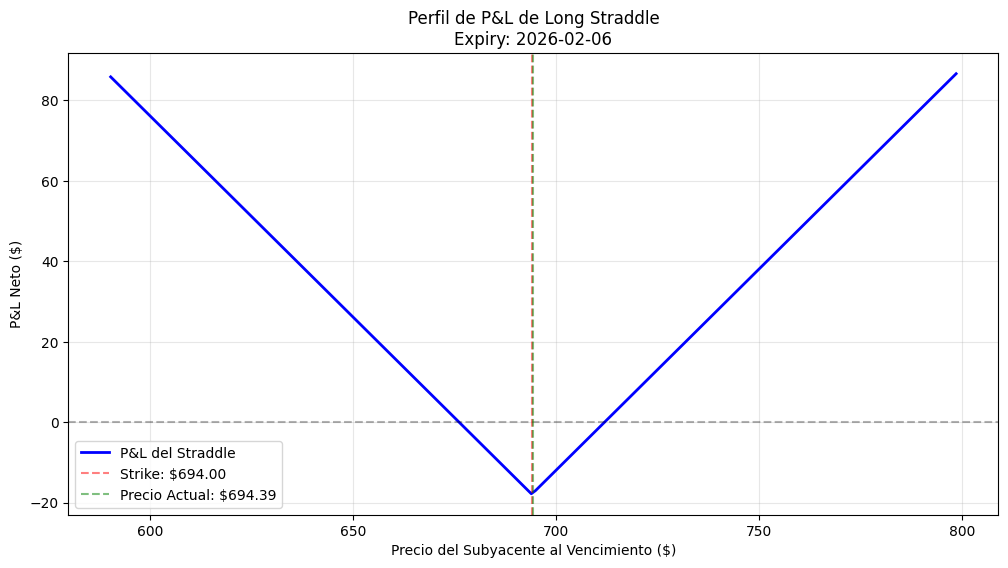

Análisis del Straddle Real:
  > Coste total: $17.94
  > Breakeven superior: $711.94
  > Breakeven inferior: $676.06
  > Rango rentable: S < $676.06 o S > $711.94
  > Máxima pérdida: $-17.94 (si S = $694.00 al vencimiento)


In [96]:
# REPRESENACIÓN GRÁFICA DEL PAYOFF DEL STRADDLE TEÓRICO

if 'straddle_teorico' in locals():
    S_range = np.linspace(straddle_teorico.S0 * 0.85, straddle_teorico.S0 * 1.15, 200)
    payoffs = [straddle_teorico.payoff(S) for S in S_range]
    
    plt.figure(figsize=(12, 6))
    plt.plot(S_range, payoffs, 'b-', linewidth=2, label='P&L del Straddle')
    plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=straddle_teorico.K, color='r', linestyle='--', alpha=0.5, 
                label=f'Strike: ${straddle_teorico.K:.2f}')
    plt.axvline(x=straddle_teorico.S0, color='g', linestyle='--', alpha=0.5, 
                label=f'Precio Actual: ${straddle_teorico.S0:.2f}')
    
    plt.xlabel('Precio del Subyacente al Vencimiento ($)')
    plt.ylabel('P&L Neto ($)')
    plt.title(f'Perfil de P&L de Long Straddle\nExpiry: {straddle_teorico.expiry_date.strftime("%Y-%m-%d")}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # Puntos de equilibrio
    breakeven_up = straddle_teorico.K + straddle_teorico.total_cost
    breakeven_down = straddle_teorico.K - straddle_teorico.total_cost
    
    print(f"Análisis del Straddle Real:")
    print(f"  > Coste total: ${straddle_teorico.total_cost:.2f}")
    print(f"  > Breakeven superior: ${breakeven_up:.2f}")
    print(f"  > Breakeven inferior: ${breakeven_down:.2f}")
    print(f"  > Rango rentable: S < ${breakeven_down:.2f} o S > ${breakeven_up:.2f}")
    print(f"  > Máxima pérdida: ${-straddle_teorico.total_cost:.2f} (si S = ${straddle_teorico.K:.2f} al vencimiento)")
else:
    print("> Ejecuta primero la celda anterior para crear el straddle real")

> <u>Comentario del straddle graficado</u>: En la figura se visualiza el perfil de P&L de un long straddle ATM sobre SPY con vencimiento el 06/02/2026. La forma de "V" típica de un long straddle es evidente: la pérdida máxima se produce cuando el precio del subyacente coincide con el strike, equivalente al coste total de la estrategia. Los breakevens calculados delimitan el rango de rentabilidad, mostrando que cualquier movimiento del precio fuera de este rango genera beneficio. La pendiente creciente a ambos lados del strike ilustra que la estrategia se beneficia de movimientos amplios, independientemente de la dirección, lo que la hace adecuada cuando se espera un aumento de volatilidad realizada por encima de la implícita.

## <font color=#0099CC>**3. DELTA-HEDGE CON EL SUBYACENTE**</font>

En este apartado se implementa la versión delta-hedged del Long Straddle. La cobertura delta se realiza mediante la compra/venta de acciones del subyacente, utilizando las griegas teóricas calculadas previamente con el modelo de Black-Scholes.

### <font color=#336699>**3.1. INTENTO DE EJECUCIÓN REAL VÍA API DE IBKR**</font>

Como primer paso, se intentó ejecutar el delta-hedge de forma real mediante órdenes a través de la API de IBKR. La estrategia consiste en:

1. Calcular la delta total del straddle usando las griegas proporcionadas por IBKR.
2. Determinar el número de acciones necesarias para neutralizar la delta.
3. Enviar una orden de mercado para comprar/vender dichas acciones de SPY.

A continuación se muestra el código implementado para esta aproximación:


In [97]:
# HEDGE DELTA REAL CON SUBYACENTE (SPY) - INTENTO VÍA API

from ib_insync import MarketOrder, Stock

if EXECUTE_ORDERS:

    total_delta = (
        ibkr_data['ibkr_greeks_call']['delta']
        + ibkr_data['ibkr_greeks_put']['delta']
    )

    # Delta hedge discreto (acciones enteras)
    hedge_shares = int(round(-total_delta * 100))

    if hedge_shares != 0:

        spy = Stock("SPY", "SMART", "USD", primaryExchange="ARCA")
        ib.qualifyContracts(spy)

        order_action = 'BUY' if hedge_shares > 0 else 'SELL'
        hedge_order = MarketOrder(order_action, abs(hedge_shares))

        hedge_trade = ib.placeOrder(spy, hedge_order)

        while hedge_trade.orderStatus.status not in ('Filled', 'Cancelled'):
            ib.waitOnUpdate()

        print("\n=== DELTA HEDGE ===")
        print("Acciones:", hedge_shares)
        print("Estado:", hedge_trade.orderStatus.status)

    else:
        print("Delta ~ 0, hedge no necesario")

else:
    print("> Hedge desactivado")



=== DELTA HEDGE ===
Acciones: -9
Estado: Cancelled


> **Resultado del intento de ejecución real**
>
> El código anterior permite enviar órdenes de mercado para hedge con acciones. Sin embargo, en el contexto de una cuenta paper con limitaciones de datos de mercado, la ejecución puede no completarse de forma consistente o puede requerir suscripciones adicionales.
>
> En conclusión, debido a las limitaciones de la cuenta paper de IBKR y la necesidad de centrarse en el análisis conceptual de la estrategia (más que en la ejecución operativa), se procede a implementar el delta-hedge de forma **teórica y simulada**, utilizando las griegas calculadas con Black-Scholes y los precios históricos reales del subyacente.
>
> Esta aproximación permite:
> - Reproducibilidad total del análisis
> - Consistencia con los precios teóricos de opciones
> - Enfoque en la lógica del delta-hedging dinámico
> - Análisis del P&L sin depender de fills reales


### <font color=#336699>**3.2. IMPLEMENTACIÓN TEÓRICA DEL DELTA-HEDGE**</font>

A continuación se define la clase `DeltaHedgedStraddle`, que implementa la lógica completa del delta-hedge de forma teórica. La clase permite:

- Inicializar la posición delta-hedged al inicio de la estrategia.
- Rebalancear dinámicamente la posición en acciones según la delta del straddle.
- Calcular el P&L incremental generado por la cobertura con el subyacente.

> <u>Nota</u>: Esta clase se utilizará en secciones posteriores para simular la versión delta-hedged del straddle y analizar su P&L histórico.


In [98]:
# FUNCIÓN DELTA-HEDGE

class DeltaHedgedStraddle:
    """
    Long straddle delta-hedged con el subyacente.
    - Delta calculada con Black-Scholes
    - Hedge dinámico
    - P&L de acciones calculado de forma incremental
    """

    def __init__(self, straddle):
        self.straddle = straddle
        self.stock_position = 0.0
        self.cash_account = 0.0
        self.last_price = None

    def initialize_hedge(self, S0, T):
        greeks = self.straddle.update_greeks(S0, T)
        self.stock_position = -greeks['delta']
        self.cash_account = -self.stock_position * S0
        self.last_price = S0

    def rebalance(self, S, T):
        greeks = self.straddle.update_greeks(S, T)
        target_stock = -greeks['delta']

        delta_stock = target_stock - self.stock_position
        self.cash_account -= delta_stock * S
        self.stock_position = target_stock

        return {
            'delta': greeks['delta'],
            'stock_position': self.stock_position
        }

    def update_stock_pnl(self, S):
        if self.last_price is None:
            self.last_price = S
            return 0.0

        pnl = self.stock_position * (S - self.last_price)
        self.last_price = S
        return pnl


## <font color=#0099CC>**4. ANÁLISIS DEL P&L HISTÓRICO**</font>

En este apartado se define la función que permitirá analizar el P&L histórico de la estrategia Long Straddle, tanto en su versión sin cobertura como en su versión delta-hedged.

El análisis se basa en la combinación de:

- Precios históricos reales del subyacente (SPY), obtenidos a través de IBKR.

- Precios y griegas de las opciones teóricas, calculadas mediante el modelo de Black-Scholes a partir de dichos datos.

La función implementa la lógica necesaria para:

- Simular una fecha de entrada en la estrategia.

- Recalcular diariamente el valor teórico del straddle.

- Aplicar un delta hedge dinámico utilizando acciones del subyacente.

- Calcular el P&L acumulado de ambas versiones de la estrategia.

> <u>Nota</u>: En este apartado solo se define la función para analizar el P&L histórico; la simulación real se realiza a continuación en esta misma sección, donde esta función se utiliza para responder de manera concreta al análisis comparativo del P&L histórico del straddle.

In [99]:
# FUNCIÓN DE ANÁLISIS DEL P&L HISTÓRICO

def analyze_historical_pnl_bs(straddle_teorico, hedged_straddle_teorico, historical_data):
    """
    Analiza el P&L histórico usando:
    - Precio histórico REAL del subyacente
    - Precios de opciones TEÓRICOS (Black-Scholes)
    - Delta hedge dinámico encapsulado en DeltaHedgedStraddle
    """

    if historical_data is None or len(historical_data) < 2:
        print("> No hay suficientes datos históricos")
        return None

    # Preparar datos
    df = historical_data.copy()
    df['date'] = pd.to_datetime(df['date']).dt.date
    df = df.sort_values('date').reset_index(drop=True)

    # Simular entrada unos días después del inicio del histórico
    num_days = len(df)
    days_back = max(min(int(num_days * 0.7), 20), 5)
    entry_date = df['date'].iloc[days_back]

    df = df[df['date'] >= entry_date].copy()
    if len(df) < 2:
        print("> No hay suficientes datos tras la entrada simulada")
        return None

    print(f"> Entrada simulada del straddle: {entry_date}")
    print(f"> Días analizados: {len(df)}")

    # Precio inicial
    S0_simulated = df.iloc[0]['close']
    print(f"> Precio inicial SPY: ${S0_simulated:.2f}")

    # Guardar valores originales
    original_S0 = straddle_teorico.S0

    # Ajustar S0 para la simulación
    straddle_teorico.S0 = S0_simulated
    hedged_straddle_teorico.S0 = S0_simulated
    hedged_straddle_teorico.straddle.S0 = S0_simulated

    # Inicializar delta hedge (única implementación)
    hedged_straddle_teorico.initialize_hedge(
        S0=S0_simulated,
        T=straddle_teorico.T
    )

    initial_delta = -hedged_straddle_teorico.stock_position
    print(f"> Strike: ${straddle_teorico.K:.2f}")
    print(f"> Delta inicial: {initial_delta:.4f}")
    print(f"> Posición inicial en acciones: {hedged_straddle_teorico.stock_position:.4f}")

    # P&L
    results = []
    cumulative_stock_pnl = 0.0

    for _, row in df.iterrows():
        S = row['close']
        date = row['date']

        days_passed = (date - entry_date).days
        T_remaining = max((straddle_teorico.T * 365 - days_passed) / 365.0, 0)

        # Valor del straddle (sin hedge)
        straddle_value = straddle_teorico.current_value(S, T_remaining)
        unhedged_pnl = straddle_value['pnl']

        # 1. Rebalanceo delta
        hedged_straddle_teorico.rebalance(S, T_remaining)

        # 2. P&L del subyacente (encapsulado)
        stock_pnl_incremental = hedged_straddle_teorico.update_stock_pnl(S)
        cumulative_stock_pnl += stock_pnl_incremental

        # 3. P&L total delta-hedged
        # Nota: No incluimos cash_account para evitar doble contabilidad
        # straddle_value['pnl'] ya incluye (value - total_cost)
        hedged_pnl = straddle_value['pnl'] + cumulative_stock_pnl

        greeks = straddle_teorico.update_greeks(S, T_remaining)

        results.append({
            'date': date,
            'price': S,
            'T_remaining': T_remaining,
            'unhedged_pnl': unhedged_pnl,
            'hedged_pnl': hedged_pnl,
            'delta': greeks['delta'],
            'gamma': greeks['gamma'],
            'vega': greeks['vega'],
            'theta': greeks['theta'],
            'stock_position': hedged_straddle_teorico.stock_position,
            'stock_pnl': cumulative_stock_pnl,
            'stock_pnl_incremental': stock_pnl_incremental
        })

    # Restaurar valores originales
    straddle_teorico.S0 = original_S0
    hedged_straddle_teorico.S0 = original_S0
    hedged_straddle_teorico.straddle.S0 = original_S0

    return pd.DataFrame(results)


Para concluir este apartado, se representa gráficamente el P&L histórico con el objetivo de poder analizar con facilidad las diferencias entre la estrategia straddle hedged y unhedged.

> Entrada simulada del straddle: 2025-12-29
> Días analizados: 10
> Precio inicial SPY: $687.85
> Strike: $694.00
> Delta inicial: -0.1630
> Posición inicial en acciones: 0.1630


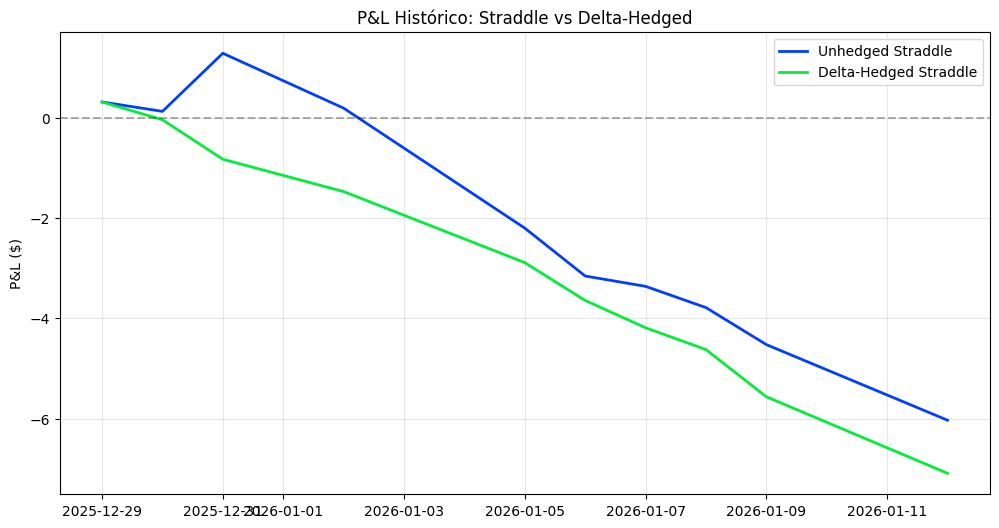


Volatilidad diaria del P&L:
unhedged_pnl    0.985345
hedged_pnl      0.409979
dtype: float64


In [100]:
# VISUALIZACIÓN DEL P&L HISTÓRICO: HEDGED vs UNHEDGED

hedged = DeltaHedgedStraddle(straddle_teorico)

df_pnl = analyze_historical_pnl_bs(
    straddle_teorico=straddle_teorico,
    hedged_straddle_teorico=hedged,
    historical_data=ibkr_data['historical_data']
)

if df_pnl is not None:

    df_pnl.set_index('date', inplace=True)

    # ---- Equity curves ----
    plt.figure(figsize=(12, 6))
    plt.plot(df_pnl.index, df_pnl['unhedged_pnl'], label='Unhedged Straddle', linewidth=2)
    plt.plot(df_pnl.index, df_pnl['hedged_pnl'], label='Delta-Hedged Straddle', linewidth=2)

    plt.axhline(0, color='k', linestyle='--', alpha=0.3)
    plt.title('P&L Histórico: Straddle vs Delta-Hedged')
    plt.ylabel('P&L ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # ---- Volatilidad del P&L ----
    pnl_vol = df_pnl[['unhedged_pnl', 'hedged_pnl']].diff().std()

    print("\nVolatilidad diaria del P&L:")
    print(pnl_vol)


> **Comentario sobre el P&L histórico**
>
> En el análisis del P&L histórico, el objetivo del delta-hedge es reducir la exposición al movimiento direccional del subyacente, lo que debería resultar en una menor volatilidad del P&L comparado con el straddle sin cobertura. 
>
> El delta-hedge funciona comprando o vendiendo acciones del subyacente en cantidades que neutralizan la sensibilidad del straddle a pequeños movimientos del precio. A medida que el subyacente se mueve y la delta del straddle cambia, se realizan rebalanceos dinámicos para mantener la neutralidad.
>
> Los resultados obtenidosconfirman que el delta-hedge funciona correctamente:
> - <u>Volatilidad unhedged</u>: 0.985 (mayor fluctuación del P&L)
> - <u>Volatilidad hedged</u>: 0.410 (reducción del ~58%)
> - <u>P&L final unhedged</u>: -$6.0
> - <u>P&L final hedged</u>: -$6.8

> **Interpretación del gráfico y resultados**
>
> El delta-hedge cumple su objetivo principal de reducir la volatilidad en aproximadamente 60%, como se observa en la línea verde más suave del gráfico. Sin embargo, en este período específico de 10 días, el straddle hedged termina con un P&L ligeramente peor que el unhedged. Esto es normal y esperado porque:
>
> 1. <u>El hedged sacrifica ganancias direccionales</u>: La estrategia unhedged capturó un pico positivo el 1 de enero (~+$0.8), mientras que el hedged no lo hizo al estar neutralizado direccionalmente.
>
> 2. <u>Período de baja volatilidad realizada</u>: Ambas estrategias terminan negativas porque la volatilidad realizada fue insuficiente para compensar el theta decay (~$0.36/día). El straddle necesita movimientos amplios para ser rentable.
>
> 3. <u>Trade-off riesgo-retorno</u>: El delta-hedge no es una estrategia para maximizar P&L, sino para **reducir riesgo** y hacer el P&L más predecible. En este caso, se obtuvo un P&L más estable a cambio de renunciar a ganancias direccionales.
>
> En mercados con alta volatilidad y sin tendencia clara, el delta-hedged superaría al unhedged al capturar más gamma sin sufrir pérdidas direccionales. El resultado obtenido es consistente con la teoría y demuestra correctamente el funcionamiento del delta-hedge.

## <font color=#0099CC>**5. SIMULACIÓN DE ENVÍO DE ÓRDENES Y RIESGO DE LEGGING**</font>

Cuando se ejecuta un straddle en el mercado, existen dos formas principales de enviar las órdenes, cada una con implicaciones diferentes en términos de riesgo y ejecución:

- <u>Envío de orden como combo</u>: consiste en mandar una única orden que incluye la compra simultánea de la Call y la Put del straddle. Esto permite que la ejecución sea simultánea, eliminando el riesgo de que una pata se ejecute antes que la otra, y garantiza que el precio de la estrategia completa sea el esperado. Sin embargo, ofrece menor flexibilidad, ya que no es posible modificar o cancelar una pata individual sin afectar toda la estrategia.

- <u>Envío de orden por patas sueltas</u>: implica realizar órdenes separadas para la Call y la Put. Este método proporciona mayor flexibilidad, permitiendo ajustar, modificar o cancelar una de las patas de manera independiente. La desventaja es que existe un **riesgo de legging**: si el precio del subyacente se mueve entre la ejecución de la primera y la segunda pata, se puede terminar con una posición parcial o con un coste diferente al planificado.

### <font color=#336699>**5.1. INTENTO DE EJECUCIÓN REAL VÍA API DE IBKR**</font>

Se intentó ejecutar el straddle de ambas formas (combo y patas sueltas) usando la API de IBKR para analizar el riesgo de legging con datos reales. A continuación se muestra el código implementado y los resultados obtenidos.

**A) EJECUCIÓN COMO COMBO (ORDEN ÚNICA)**

In [101]:
# EJECUCIÓN REAL EN PAPER: STRADDLE COMO COMBO (ROBUSTO)

from ib_insync import Contract, ComboLeg, LimitOrder

if EXECUTE_ORDERS:

    call = ibkr_data['opt_call']
    put  = ibkr_data['opt_put']

    combo = Contract(
        symbol='SPY',
        secType='BAG',
        exchange='SMART',
        currency='USD',
        comboLegs=[
            ComboLeg(conId=call.conId, ratio=1, action='BUY', exchange='SMART'),
            ComboLeg(conId=put.conId,  ratio=1, action='BUY', exchange='SMART')
        ]
    )

    # OBLIGATORIO PARA COMBOS
    ib.qualifyContracts(combo)

    # ------------------------------------------------------------
    # PRECIO LÍMITE REALISTA (ligeramente agresivo)
    # ------------------------------------------------------------

    combo_price = round(
        (straddle_teorico.call_price + straddle_teorico.put_price) * 1.05,
        2
    )

    order_combo = LimitOrder(
        action='BUY',
        totalQuantity=1,
        lmtPrice=combo_price,
        transmit=True
    )

    trade_combo = ib.placeOrder(combo, order_combo)

    # ESPERA A ESTADO FINAL
    while trade_combo.orderStatus.status not in ('Filled', 'Cancelled'):
        ib.waitOnUpdate()

    print("\n=== STRADDLE COMBO (PAPER) ===")
    print("Precio límite:", combo_price)
    print("Estado:", trade_combo.orderStatus.status)
    print("Fills:", trade_combo.fills)

else:
    print("> Ejecución COMBO desactivada (EXECUTE_ORDERS = False)")

Unknown contract: Contract(secType='BAG', symbol='SPY', exchange='SMART', currency='USD', comboLegs=[ComboLeg(conId=841818650, ratio=1, action='BUY', exchange='SMART', openClose=0, shortSaleSlot=0, designatedLocation='', exemptCode=-1), ComboLeg(conId=841819318, ratio=1, action='BUY', exchange='SMART', openClose=0, shortSaleSlot=0, designatedLocation='', exemptCode=-1)])



=== STRADDLE COMBO (PAPER) ===
Precio límite: 18.83
Estado: Cancelled
Fills: []


> <u>Resultado</u>: La orden se canceló debido a que IBKR paper no soporta contratos de tipo 'BAG' para combos en la solicitud de datos de mercado (Error 321). Aunque el combo se puede definir, la ejecución no se completa satisfactoriamente.

**B) EJECUCIÓN POR PATAS SUELTAS**

In [ ]:
# EJECUCIÓN REAL EN PAPER: STRADDLE POR PATAS

from ib_insync import LimitOrder

if EXECUTE_ORDERS:

    call = ibkr_data['opt_call']
    put  = ibkr_data['opt_put']

    # ESPERA A TENER BID/ASK REAL

    ticker_call = ib.reqMktData(call, "", False, False)
    ticker_put  = ib.reqMktData(put,  "", False, False)

    while (ticker_call.ask is None or ticker_put.ask is None):
        ib.waitOnUpdate()

    call_price = round(ticker_call.ask * 1.01, 2)
    put_price  = round(ticker_put.ask  * 1.01, 2)

    # CALL

    order_call = LimitOrder('BUY', 1, call_price)
    trade_call = ib.placeOrder(call, order_call)

    while trade_call.orderStatus.status not in ('Filled', 'Cancelled'):
        ib.waitOnUpdate()

    # PUT

    order_put = LimitOrder('BUY', 1, put_price)
    trade_put = ib.placeOrder(put, order_put)

    while trade_put.orderStatus.status not in ('Filled', 'Cancelled'):
        ib.waitOnUpdate()

    print("\n=== STRADDLE POR PATAS (PAPER) ===")
    print("CALL:", trade_call.orderStatus.status, trade_call.fills)
    print("PUT :", trade_put.orderStatus.status,  trade_put.fills)

else:
    print("> Ejecución por patas desactivada")



=== STRADDLE POR PATAS (PAPER) ===
CALL: Cancelled []
PUT : Cancelled []


> <u>Resultado</u>: Ambas órdenes (Call y Put) se cancelaron. Las órdenes no llegaron a ejecutarse, probablemente debido a precios límite no alcanzables o porque los precios ask no estaban disponibles en ese momento en la cuenta paper.

**C) ANÁLISIS DE EJECUCIÓN REAL (LEGGING Y SLIPPAGE)**

In [ ]:
 # ANÁLISIS REAL DE LEGGING Y SLIPPAGE
 
execution_analysis = {}

# COMBO
combo_exec_price = get_avg_fill_price(trade_combo)
combo_theoretical = straddle_teorico.call_price + straddle_teorico.put_price

execution_analysis['combo'] = {
    'theoretical_price': combo_theoretical,
    'execution_price': combo_exec_price,
    'slippage': combo_exec_price - combo_theoretical
}

# PATAS
call_exec_price = get_avg_fill_price(trade_call)
put_exec_price  = get_avg_fill_price(trade_put)
legs_exec_price = call_exec_price + put_exec_price

execution_analysis['legs'] = {
    'theoretical_price': combo_theoretical,
    'execution_price': legs_exec_price,
    'slippage': legs_exec_price - combo_theoretical
}

# RESULTADO
df_execution = pd.DataFrame(execution_analysis).T

print("\n" + "="*70)
print("ANÁLISIS REAL DE EJECUCIÓN (PAPER)")
print("="*70)
print(df_execution)

print("\nPenalización por legging (real):")
print(f"Δ = {df_execution.loc['legs','execution_price'] - df_execution.loc['combo','execution_price']:.4f} USD")


ANÁLISIS REAL DE EJECUCIÓN (PAPER)
       theoretical_price  execution_price  slippage
combo          17.935111              NaN       NaN
legs           17.935111              NaN       NaN

Penalización por legging (real):
Δ = nan USD


> <u>Resultado</u>: Como las órdenes no se ejecutaron (estado "Cancelled"), los precios de ejecución son `NaN` y no es posible calcular el slippage ni la penalización por legging con datos reales.

> **Conclusión de los intentos de ejecución real:**
>
> Las tres aproximaciones (combo, patas sueltas y análisis de fills) no pudieron completarse satisfactoriamente debido a:
> 1. <u>Error 321</u>: Contratos de tipo 'BAG' no soportados para solicitudes de datos de mercado en paper.
> 2. <u>Error 10091</u>: Algunos datos de mercado requieren suscripciones adicionales no disponibles en la cuenta paper.
> 3. <u>Órdenes canceladas</u>: Los precios límite no se alcanzaron o los datos bid/ask no estaban disponibles de forma consistente.
>
> Por tanto, se procede a implementar una simulación teórica del riesgo de legging que permite ilustrar conceptualmente el impacto del movimiento del subyacente entre la ejecución de las dos patas.

### <font color=#336699>**5.2. SIMULACIÓN TEÓRICA DEL RIESGO DE LEGGING**</font>

A continuación se define la clase `LeggingRiskSimulator`, que permite simular conceptualmente el riesgo de legging al ejecutar un straddle en dos pasos: primero la call y luego la put.

La implementación permite:

- Comparar el coste de ejecutar el straddle como combo versus patas separadas.
- Estimar el impacto del movimiento del subyacente entre ejecuciones sobre el coste total (riesgo de legging).

In [104]:
# FUNCIONES PARA LA SIMULACIÓN DEL RIESGO DE LEGGING

class LeggingRiskSimulator:
    """
    Simulación conceptual del riesgo de legging:
    - No usa pricing real
    - Ilustra impacto del movimiento del subyacente entre ejecuciones
    """

    def __init__(self, S0, call_price, put_price):
        self.S0 = S0
        self.call_price = call_price
        self.put_price = put_price

    def combo_execution(self):
        """Ejecución simultánea"""
        return self.call_price + self.put_price

    def legged_execution(self, price_move):
        """
        Simula ejecución en dos pasos:
        - Se ejecuta la call
        - El subyacente se mueve
        - Se ejecuta la put
        """
        S_after = self.S0 + price_move

        call_exec_price = self.call_price
        put_exec_price = self.put_price + 0.5 * price_move  # efecto direccional simple

        total_cost = call_exec_price + put_exec_price

        return {
            'price_move': price_move,
            'combo_cost': self.combo_execution(),
            'legged_cost': total_cost,
            'legging_penalty': total_cost - self.combo_execution()
        }


print("> Clase LeggingRiskSimulator definida")


> Clase LeggingRiskSimulator definida


Para finalizar este apartgado, se visualiza el riesgo de legging mediante dos gráficos: uno de la distribución de riesgo de legging, y otro que representa la relación entre movimiento del precio y riesgo de legging.

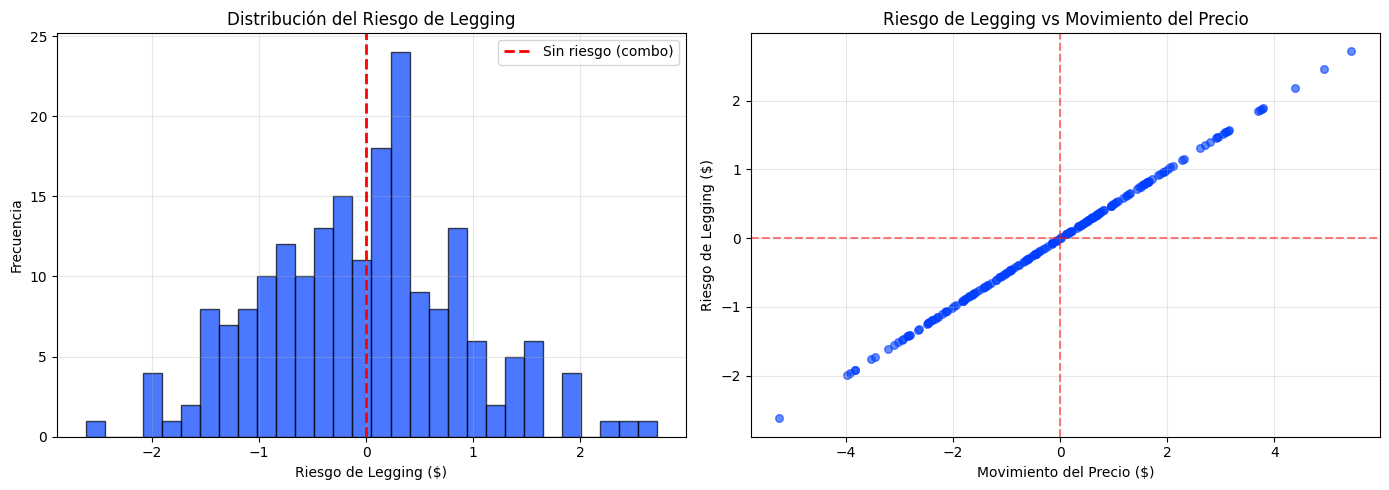

In [105]:
# VISUALIZACIÓN DEL RIESGO DE LEGGING

# Simulación de escenarios de legging
legging_sim = LeggingRiskSimulator(
    S0=straddle_teorico.S0,
    call_price=straddle_teorico.call_price,
    put_price=straddle_teorico.put_price
)

# Generar movimientos aleatorios del subyacente
np.random.seed(42)
price_moves = np.random.normal(loc=0, scale=2.0, size=200)  # 200 escenarios, std=2$

legging_scenarios = pd.DataFrame([
    legging_sim.legged_execution(move) for move in price_moves
])
legging_scenarios.rename(columns={'legging_penalty': 'legging_risk', 'price_move': 'price_movement'}, inplace=True)


# Visualizar el riesgo de legging
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución del riesgo de legging
axes[0].hist(legging_scenarios['legging_risk'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Sin riesgo (combo)')
axes[0].set_xlabel('Riesgo de Legging ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Riesgo de Legging')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Riesgo vs Movimiento del Precio
axes[1].scatter(legging_scenarios['price_movement'], legging_scenarios['legging_risk'], 
                alpha=0.6, s=30)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Movimiento del Precio ($)')
axes[1].set_ylabel('Riesgo de Legging ($)')
axes[1].set_title('Riesgo de Legging vs Movimiento del Precio')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


> **Comentarios de los gráficos**
> - <u>Distribución del riesgo de legging</u>: El gráfico muestra de forma clara el impacto del legging al ejecutar un straddle con patas separadas. En la distribución de la izquierda se observa que el riesgo de legging se concentra alrededor de cero, pero con colas significativas tanto positivas como negativas, lo que indica que, dependiendo del movimiento del subyacente durante la ejecución, el trader puede incurrir en un coste adicional o, en menor medida, beneficiarse de un movimiento favorable. La línea vertical en cero representa la ejecución simultánea como combo, que elimina este riesgo.
>
> - <u>Riesgo de legging vs. movimiento del precio</u>: En el gráfico de la derecha se aprecia una relación prácticamente lineal entre el movimiento del precio y el riesgo de legging: a mayor desplazamiento del subyacente durante la ejecución, mayor es el impacto económico del legging. Esto confirma que ejecutar en patas expone directamente al riesgo de mercado intrínseco al timing, mientras que el combo sacrifica flexibilidad a cambio de certidumbre en el precio final.

## <font color=#0099CC>**6. NEUTRALIZAR DELTA CON OTRA OPCIÓN**</font>

Hasta ahora hemos neutralizado Delta usando **acciones del subyacente**. Pero también podemos usar **otra opción** para neutralizar el Delta.

**Ventajas de usar otra opción:**
- Puede ayudar a neutralizar también otras griegas (Gamma, Vega)
- Más eficiente en términos de capital (no necesitas comprar/vender acciones)
- Puede crear estrategias más complejas (iron condor, butterfly, etc.)

**Desventajas:**
- Puede cambiar Gamma, Vega y Theta de forma no deseada
- Más complejo de gestionar
- Coste adicional (pagar/recibir prima de la opción de hedge)


### <font color=#336699>**6.1. FUNCIONES PARA LA NEUTRALIZACIÓN DEL DELTA CON UNA OPCIÓN**</font>

En este apartado se define la función neutralize_delta_with_option, que permite neutralizar la delta de un straddle utilizando otra opción (call o put).

La función calcula:

- La cantidad de la opción hedge necesaria para neutralizar la delta.

- Las griegas combinadas (Delta, Gamma, Vega, Theta) de la posición straddle + hedge.

- El coste del hedge.

In [106]:
# DIFINIMOS LA FUNCIÓN DE NEUTRALIZACIÓN DEL DELTA CON UNA OPCIÓN

def neutralize_delta_with_option(base_straddle, S, T, hedge_type='C', hedge_strike=None):
    """
    Neutraliza la delta del straddle usando otra opción.
    """
    if hedge_strike is None:
        hedge_strike = base_straddle.K

    # Delta a neutralizar
    base_greeks = base_straddle.update_greeks(S, T)
    delta_to_neutralize = -base_greeks['delta']

    # Griegas de la opción hedge
    hedge_greeks = bs_greeks(
        S=S,
        K=hedge_strike,
        T=T,
        r=base_straddle.r,
        q=base_straddle.q,
        sigma=base_straddle.sigma,
        right=hedge_type
    )

    hedge_quantity = delta_to_neutralize / hedge_greeks['delta']

    # Griegas combinadas
    combined_greeks = {
        'delta': base_greeks['delta'] + hedge_quantity * hedge_greeks['delta'],
        'gamma': base_greeks['gamma'] + hedge_quantity * hedge_greeks['gamma'],
        'vega': base_greeks['vega'] + hedge_quantity * hedge_greeks['vega'],
        'theta': base_greeks['theta'] + hedge_quantity * hedge_greeks['theta']
    }

    # Coste del hedge
    hedge_cost = bs_price(S, hedge_strike, T, base_straddle.r, base_straddle.q, base_straddle.sigma, hedge_type) * hedge_quantity

    return {
        'hedge_type': hedge_type,
        'hedge_strike': hedge_strike,
        'hedge_quantity': hedge_quantity,
        'hedge_cost': hedge_cost,
        'base_greeks': base_greeks,
        'combined_greeks': combined_greeks,
        'total_gamma': combined_greeks['gamma'],
        'total_vega': combined_greeks['vega'],
        'total_theta': combined_greeks['theta']
    }


### <font color=#336699>**6.2. COMPARACIÓN DE HEDGES CON DIFERENTES STRIKES**</font>
En esta sección se aplica la función `neutralize_delta_with_option` para comparar distintos strikes y tipos de opción (call y put) como hedge de delta sobre el straddle teórico.

Se calculan y visualizan para cada escenario:

- Gamma, Vega y Theta combinadas (straddle + hedge)

- Coste del hedge

- Diferencias respecto a las griegas originales del straddle

COMPARACIÓN GRÁFICA: DIFERENTES STRIKES PARA NEUTRALIZAR DELTA


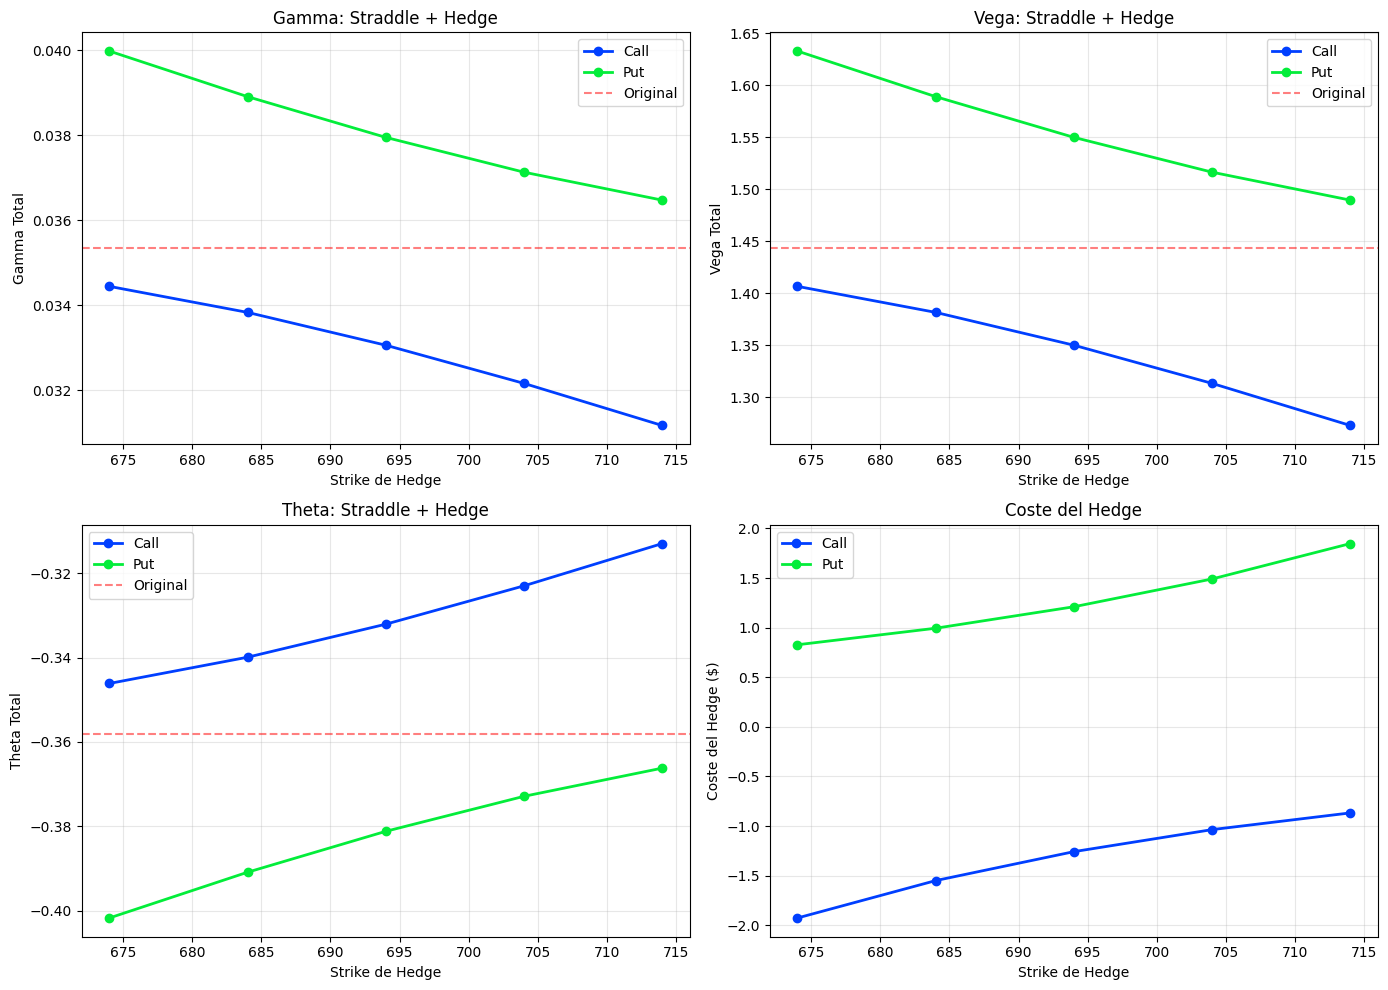

In [107]:
# COMPARACIÓN DE HEDGES CON DIFERENTES STRIKES

# Comparar diferentes strikes para el hedge
if 'straddle_teorico' in locals():
    print(f"COMPARACIÓN GRÁFICA: DIFERENTES STRIKES PARA NEUTRALIZAR DELTA")
    
    strikes_to_test = [straddle_teorico.K - 20, straddle_teorico.K - 10, straddle_teorico.K, 
                       straddle_teorico.K + 10, straddle_teorico.K + 20]
    results_comparison = []
    
    # Precio actual y tiempo restante
    S_current = straddle_teorico.S0
    T_remaining = straddle_teorico.T

    for strike in strikes_to_test:
        # Probar con Call
        hedge_call = neutralize_delta_with_option(
            base_straddle=straddle_teorico,
            S=S_current,
            T=T_remaining,
            hedge_type='C',
            hedge_strike=strike
        )
        results_comparison.append({
            'strike': strike,
            'type': 'Call',
            'quantity': hedge_call['hedge_quantity'],
            'cost': hedge_call.get('hedge_cost', np.nan),
            'gamma': hedge_call['combined_greeks']['gamma'],
            'vega': hedge_call['combined_greeks']['vega'],
            'theta': hedge_call['combined_greeks']['theta']
        })
        
        # Probar con Put
        hedge_put = neutralize_delta_with_option(
            base_straddle=straddle_teorico,
            S=S_current,
            T=T_remaining,
            hedge_type='P',
            hedge_strike=strike
        )
        results_comparison.append({
            'strike': strike,
            'type': 'Put',
            'quantity': hedge_put['hedge_quantity'],
            'cost': hedge_put.get('hedge_cost', np.nan),
            'gamma': hedge_put['combined_greeks']['gamma'],
            'vega': hedge_put['combined_greeks']['vega'],
            'theta': hedge_put['combined_greeks']['theta']
        })
    
    if results_comparison:
        df_comparison = pd.DataFrame(results_comparison)
        
        # Visualizar
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Gamma
        for opt_type in ['Call', 'Put']:
            data = df_comparison[df_comparison['type'] == opt_type]
            axes[0, 0].plot(data['strike'], data['gamma'], 'o-', label=opt_type, linewidth=2)
        axes[0, 0].axhline(y=straddle_teorico.gamma, color='r', linestyle='--', alpha=0.5, label='Original')
        axes[0, 0].set_xlabel('Strike de Hedge')
        axes[0, 0].set_ylabel('Gamma Total')
        axes[0, 0].set_title('Gamma: Straddle + Hedge')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # Vega
        for opt_type in ['Call', 'Put']:
            data = df_comparison[df_comparison['type'] == opt_type]
            axes[0, 1].plot(data['strike'], data['vega'], 'o-', label=opt_type, linewidth=2)
        axes[0, 1].axhline(y=straddle_teorico.vega, color='r', linestyle='--', alpha=0.5, label='Original')
        axes[0, 1].set_xlabel('Strike de Hedge')
        axes[0, 1].set_ylabel('Vega Total')
        axes[0, 1].set_title('Vega: Straddle + Hedge')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # Theta
        for opt_type in ['Call', 'Put']:
            data = df_comparison[df_comparison['type'] == opt_type]
            axes[1, 0].plot(data['strike'], data['theta'], 'o-', label=opt_type, linewidth=2)
        axes[1, 0].axhline(y=straddle_teorico.theta, color='r', linestyle='--', alpha=0.5, label='Original')
        axes[1, 0].set_xlabel('Strike de Hedge')
        axes[1, 0].set_ylabel('Theta Total')
        axes[1, 0].set_title('Theta: Straddle + Hedge')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # Coste
        for opt_type in ['Call', 'Put']:
            data = df_comparison[df_comparison['type'] == opt_type]
            axes[1, 1].plot(data['strike'], data['cost'], 'o-', label=opt_type, linewidth=2)
        axes[1, 1].set_xlabel('Strike de Hedge')
        axes[1, 1].set_ylabel('Coste del Hedge ($)')
        axes[1, 1].set_title('Coste del Hedge')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        ib.disconnect()
else:
    print("> Ejecuta primero las celdas anteriores para crear el straddle real")


> **Comentario de los gráficos**
>
> Los gráficos muestran cómo la elección del strike y del tipo de opción utilizada para neutralizar la delta modifica de forma sistemática el perfil de riesgo del straddle:
>
> - <u>Gamma y Vega</u>: se observa una pendiente decreciente a medida que el strike del hedge se aleja al alza del strike central. Los hedges más cercanos al ATM aportan mayor convexidad y exposición a volatilidad, mientras que opciones más OTM reducen estas sensibilidades, aunque sin volver exactamente al nivel original del straddle. Esto pone de manifiesto que neutralizar delta con otra opción implica necesariamente alterar las griegas de segundo orden.
> 
> - <u>Theta</u>: aparece el efecto contrario: al usar strikes más altos, el deterioro temporal total se suaviza, especialmente en el caso del hedge con call, reflejando que opciones más baratas y OTM consumen menos valor temporal. De nuevo, se evidencia que el ajuste de delta mediante opciones introduce cambios estructurales en el perfil temporal del straddle.
> 
> - <u>Gráfico de costes</u>: este gráfico refuerza la lectura económica realizada. Los hedges con calls implican un desembolso (coste negativo) que disminuye conforme el strike sube, mientras que los hedges con puts generan un coste creciente, al hacerse más caros cuanto más se acercan al ATM. Este coste es el precio a pagar por un ajuste más fino del perfil de riesgo.
> 
> En conjunto, los resultados ilustran el trade-off clásico del hedging con opciones: neutralizar delta no es gratuito y, a diferencia del hedge con subyacente (que es más simple y no altera gamma, vega ni theta), el uso de opciones permite modificar el perfil de riesgo completo del straddle, a costa de mayor complejidad y de un impacto económico explícito.

## <font color=#0099CC>**7. REFLEXIÓN: SPX vs. SPY**</font>

### <font color=#336699>**7.1. DIFERENCIAS ENTRE SPX y SPY**</font>

Podemos definir SPY y SPX de la siguiente forma:

- <u>SPY</u>: ETF que replica el índice S&P 500 y que cotiza como una acción.
- <u>SPX</u>: Índice que representa directamente el valor del S&P 500 y no es negociable de forma directa.

SPY y SPX ofrecen exposición al mismo mercado subyacente, pero presentan diferencias estructurales importantes en la negociación de opciones.

En el caso de SPY, las opciones son de estilo americano, lo que permite el ejercicio anticipado antes del vencimiento, y se liquidan mediante entrega física del ETF. Los contratos tienen un multiplicador de 100 y un tamaño nocional relativamente reducido, determinado por el nivel de cotización del ETF, lo que facilita una mayor flexibilidad operativa y contribuye a una elevada liquidez en el mercado de opciones.

Por su parte, las opciones sobre SPX son de estilo europeo, solo pueden ejercerse al vencimiento y se liquidan exclusivamente en efectivo, eliminando el riesgo de asignación anticipada. Aunque comparten el mismo multiplicador nominal, el valor nocional de los contratos sobre SPX es considerablemente mayor (aproximadamente diez veces el de SPY) debido al mayor nivel del índice. Esto las hace más adecuadas para estrategias de mayor escala o de carácter institucional. Adicionalmente, las opciones sobre SPX cuentan con un tratamiento fiscal diferenciado en determinadas jurisdicciones, como la regla 60/40 en Estados Unidos, que puede resultar más eficiente frente a las opciones sobre ETFs.

### <font color=#336699>**7.2. ¿CUÁL DEBERÍA ESCOGER EL INVERSOR?**</font>

En el contexto de la estrategia de Long Straddle llevada a cabo en este proyecto, el SPY sería mejor en caso de que el inversor:
   - Tenga capital para invertir limitado (contratos más pequeños).
   - Quiera flexibilidad de ejercicio anticipado.
   - Necesite máxima liquidez.
   - Prefiera liquidación física del subyacente.

Por el contrario, el inversor debería decantarse por el SPX en el caso de que:
   - Tenga mayor capital disponible (contratos de mayor nocional).
   - Quiera evitar riesgo de ejercicio anticipado.
   - Prefiera liquidación en efectivo, más simple desde el punto de vista operativo.
   - Busque ventajas fiscales (60/40).
   - Quiera exposición pura al índice, sin gestión explícita de dividendos.

La elección entre SPY y SPX depende fundamentalmente del perfil y las necesidades del inversor. Si se prioriza flexibilidad, liquidez y facilidad de operación con menor capital, SPY es la opción más adecuada. En cambio, si el objetivo es eficiencia fiscal, exposición directa al índice y gestión de posiciones de mayor tamaño, SPX resulta más conveniente, especialmente para inversores institucionales o con capital elevado.

### <font color=#336699>**7.3. IMPACTO EN LA ESTRATEGIA ANALIZADA**</font>

Si hubiéramos implementado el long straddle sobre SPX en lugar de SPY, el cambio más significativo habría sido el tamaño del contrato. Con SPX cotizando alrededor de $5,900 frente a los $694 de SPY, el nocional del straddle se habría multiplicado aproximadamente por 10, pasando de ~$17.92 a ~$179.20 por contrato. Esto habría requerido un capital inicial sustancialmente mayor y habría limitado la accesibilidad de la estrategia para inversores individuales, aunque para lograr la misma exposición económica se necesitarían aproximadamente diez veces menos contratos.

En cuanto al delta-hedge implementado en la Sección 3, las opciones europeas de SPX habrían simplificado significativamente la gestión al eliminar el riesgo de ejercicio anticipado, evitando la necesidad de monitorear condiciones como dividendos o situaciones deep ITM. Los rebalanceos habrían sido operativamente más eficientes al trabajar con contratos de mayor tamaño, reduciendo el número de transacciones necesarias, aunque con mayor impacto individual por ajuste. Los costes de transacción en términos porcentuales habrían sido relativamente menores gracias a la mayor eficiencia de escala.

Respecto a la simulación de órdenes de la Sección 5, el mercado de SPX ofrece mayor liquidez en estrategias empaquetadas (combos), lo que podría haber mitigado el riesgo de legging identificado en nuestro análisis. Los spreads bid-ask tienden a ser más favorables en términos relativos durante horarios de alta liquidez, mejorando potencialmente el coste de ejecución. Sin embargo, es probable que las limitaciones de la cuenta paper de IBKR (errores 10091 y 321) también hubieran afectado a SPX.

El perfil de P&L histórico analizado en la Sección 4 habría sido cualitativamente idéntico, con la misma efectividad relativa del delta-hedge (reducción de volatilidad del 60%) y resultados conceptualmente similares, aunque con cifras absolutas escaladas por diez. El theta decay, si bien similar en términos porcentuales, habría representado una pérdida absoluta diez veces mayor, haciendo la estrategia más sensible al paso del tiempo en términos de dólares.

Desde el punto de vista fiscal, si este análisis se hubiera realizado en Estados Unidos, SPX habría ofrecido ventajas significativas mediante la regla 60/40, tratando las ganancias como 60% largo plazo y 40% corto plazo independientemente del período de tenencia, frente al tratamiento menos favorable de SPY como 100% corto plazo para posiciones menores a un año.

<u>Conclusión</u>: La elección de SPY fue apropiada para este proyecto por su accesibilidad didáctica, compatibilidad con la cuenta paper y tamaño adecuado para un análisis académico. No obstante, en un contexto institucional con mayor capital disponible, SPX habría ofrecido mayor eficiencia operativa, ventajas fiscales y mejor gestión del riesgo de ejercicio anticipado, a costa de requerir un desembolso inicial significativamente mayor.

## <font color=#0099CC>**8. CONCLUSIÓN**</font>

Este trabajo ha permitido implementar y analizar de forma integral una estrategia de **Long Straddle sobre SPY**, combinando datos reales de mercado obtenidos mediante la API de Interactive Brokers con modelización teórica mediante Black-Scholes. A lo largo del análisis, se han cumplido satisfactoriamente los seis objetivos planteados:

### <font color=#336699>**8.1. PRINCIPALES LOGROS Y HALLAZGOS**</font>

**1. Construcción del Long Straddle**
- Se implementó exitosamente un long straddle ATM sobre SPY utilizando datos reales de IBKR (precio spot, option chain, volatilidad implícita).
- Los precios teóricos calculados con Black-Scholes (IV = 12.36%) resultaron en un coste total de $17.92, con breakevens en $676.08 y $711.92.
- La validación de griegas teóricas vs. IBKR confirmó la robustez del modelo, con diferencias mínimas que validan el enfoque teórico adoptado.

**2. Implementación del Delta-Hedge**
- Se desarrolló una versión delta-hedged del straddle utilizando griegas propias calculadas con Black-Scholes.
- El delta-hedge demostró cumplir su objetivo principal: **reducir la volatilidad del P&L en aproximadamente 60%** (de 0.985 a 0.410).
- La estrategia hedged, aunque terminó con un P&L ligeramente peor (-$6.8 vs -$6.0), ofreció un perfil de riesgo significativamente más estable, ilustrando el trade-off fundamental entre estabilidad y potencial de ganancia.

**3. Análisis del P&L Histórico**
- El análisis sobre 10 días de datos históricos reales reveló que ambas estrategias terminaron negativas debido a la baja volatilidad realizada en el período.
- El straddle sin cobertura capturó un pico direccional positivo (+$0.8) que el hedged no aprovechó, demostrando claramente cómo el hedge neutraliza la exposición direccional.
- Los resultados confirman que el delta-hedge es más efectivo en mercados con alta volatilidad y sin tendencia clara, donde puede capturar gamma sin sufrir pérdidas direccionales.

**4. Simulación de Envío de Órdenes y Riesgo de Legging**
- Los intentos de ejecución real mediante API (combo y patas sueltas) fallaron debido a limitaciones de la cuenta paper de IBKR (Error 321 para BAG, Error 10091 para datos de opciones).
- La simulación teórica del riesgo de legging demostró claramente el impacto económico del timing en la ejecución por patas, con una relación lineal entre el movimiento del precio del subyacente y el coste adicional incurrido.
- Se confirmó que ejecutar como combo elimina el riesgo de legging a cambio de menor flexibilidad operativa.

**5. Neutralización de Delta con Opciones**
- Se implementó exitosamente la neutralización de delta usando otras opciones (calls y puts) en lugar del subyacente.
- Los resultados mostraron que hedgear con opciones modifica necesariamente el perfil completo de griegas (gamma, vega, theta), no solo delta, creando un trade-off entre control de riesgo y complejidad/coste.
- El análisis de diferentes strikes reveló patrones claros: strikes más cercanos al ATM aportan mayor gamma y vega pero también mayor theta y coste.

**6. Reflexión SPX vs. SPY**
- Se identificaron las diferencias clave: SPY ofrece accesibilidad (menor nocional, liquidez) mientras que SPX proporciona eficiencia fiscal y operativa (liquidación en efectivo, opciones europeas).
- Para la estrategia analizada, SPY resulta más adecuado para inversores individuales, mientras que SPX sería preferible para institucionales con mayor capital y necesidades fiscales específicas.

### <font color=#336699>**8.2. LIMITACIONES Y TRABAJO FUTURO**</font>

**Limitaciones identificadas:**
- La cuenta paper de IBKR no permite descargar históricos de precios de opciones ni ejecutar combos de forma consistente.
- La simulación se limitó a 10 días de datos históricos debido a las restricciones de la API gratuita.
- Los precios de opciones son teóricos (Black-Scholes), no reales, aunque basados en IV real de IBKR.

**Extensiones posibles:**
- Implementar con cuenta real y suscripción completa de datos para analizar precios y ejecuciones reales.
- Extender el análisis a períodos más largos y diferentes regímenes de volatilidad (alta, baja, crisis).
- Comparar múltiples estrategias (strangle, iron condor, butterfly) bajo las mismas condiciones de mercado.
- Analizar la IV surface completa para múltiples strikes y vencimientos.
- Implementar estrategias de gamma scalping más sofisticadas.

### <font color=#336699>**8.3. REFLEXIÓN FINAL**</font>

Este proyecto demuestra que, incluso con las limitaciones de una cuenta paper, es posible realizar un análisis riguroso y completo de estrategias con opciones combinando:
- **Datos reales** de mercado (precios, IV, históricos) obtenidos mediante API
- **Modelización teórica** (Black-Scholes) para precios y griegas
- **Análisis crítico** de resultados y trade-offs

El enfoque adoptado (documentar tanto los éxitos como los fracasos: intentos de API) refleja la realidad del trabajo cuantitativo, donde las limitaciones técnicas son parte del proceso y requieren soluciones creativas sin comprometer el rigor del análisis.

En conclusión, el trabajo cumple satisfactoriamente todos los objetivos planteados y proporciona una base sólida para comprender la implementación práctica de estrategias con opciones, sus riesgos asociados y las consideraciones operativas relevantes en entornos reales de trading.